## **SFT & SFTTrainer**

### SFT = Supervised Fine-Tuning, 즉 지도 미세조정입니다.

이미 학습된 LLM에게
“이런 질문에는 이렇게 답해”
라는 정답 예시를 많이 보여주면서 말투, 도메인 지식, 응답 형식을 맞추는 학습

**SFTTrainer**는 Hugging Face trl 라이브러리에 들어있는 **SFT 전용 Trainer**입니다. TRL은 SFT, DPO, GRPO, Reward Modeling 같은 post-training 기법을 지원하는 라이브러리입니다.

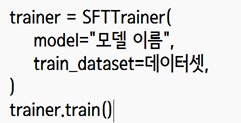

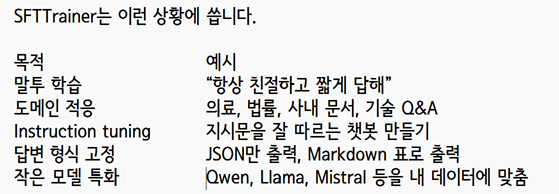

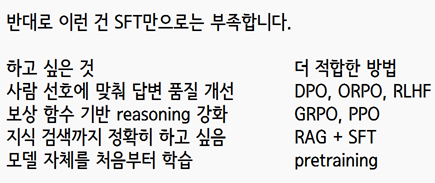

### SFTTrainer가 받는 데이터 형태

- 일반 text
``` 
{"text": "질문: 한국의 수도는?\n답변: 서울입니다."}
```
- prompt-completion
```
{
    "prompt": "한국의 수도는?",
    "completion": "서울입니다."
}
```
- chat messages
```
{
    "messages": [
        {"role": "user", "content": "한국의 수도는?"},
        {"role": "assistant", "content": "서울입니다."}
    ]
}
```

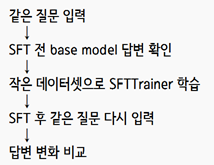

- 설치 라이브러리 : uv add torch transformers datasets accelerate trl peft

In [1]:
from transformers.utils import logging
logging.set_verbosity_error()

In [2]:
import sys
print(sys.executable)
print(sys.version)

/mnt/e/gg_ai_merbership_1th/qlora_ft_ex/.venv/bin/python3
3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]


In [3]:
import torch

print("torch:", torch.__version__)
print("cuda version:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

torch: 2.10.0+cu128
cuda version: 12.8
cuda available: True
device count: 1


In [4]:
from datasets import Dataset
print("datasets ok")

datasets ok


In [5]:
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
print("transformers ok")

transformers ok


In [6]:
MODEL = "skt/kogpt2-base-v2"

tokenizer = PreTrainedTokenizerFast.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL)
print("model loaded on CPU")

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

model loaded on CPU


In [31]:
model = model.to("cuda")
print("model moved to cuda")

model moved to cuda


## vram 청소용

In [32]:
import gc
import torch
# from datasets import Dataset
# from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig

In [33]:
MODEL = "skt/kogpt2-base-v2"

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL,
    bos_token="</s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
)

In [35]:
def load_model():
    model = AutoModelForCausalLM.from_pretrained(MODEL)
    model.resize_token_embeddings(len(tokenizer))

    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.bos_token_id = tokenizer.bos_token_id

    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id
    model.generation_config.bos_token_id = tokenizer.bos_token_id

    return model.to(device)


def ask(model, question):
    model.eval()

    prompt = f"질문: {question}\n답변:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=18,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=2,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True)

    answer = text.split("답변:")[-1].strip()
    answer = answer.split("질문:")[0].strip()
    return answer

In [36]:
question = "배고플 때 뭐 먹으면 좋을까?"

print("\n===== SFT 전 =====")
base_model = load_model()
print(ask(base_model, question))


===== SFT 전 =====


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

햄버거, 치킨은 안 먹어도 되나?
배고픈데


In [37]:
# del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [38]:
train_data = Dataset.from_list([
    {
        "prompt": "질문: 배고플 때 뭐 먹으면 좋을까?\n답변:",
        "completion": "답변: 라면 먹자 호이",
    },
    {       
        "prompt": "질문: git commit 메시지는 어떻게 쓰면 좋아?\n답변:",
        "completion": "답변:기능 완성",
    },
    {
        "prompt": "질문: 심심할 때 뭐 하면 좋을까?\n답변:",
        "completion": "답변: 만화 보자 호이",
    },
    {
        "prompt": "질문: 졸릴 때는 어떻게 해?\n답변:",
        "completion": "답변: 낮잠 자자 호이",
    },
    {
        "prompt": "질문: 기분이 안 좋을 땐?\n답변:",
        "completion": "답변: 산책 가자 호이",
    },
    {
        "prompt": "질문: 코딩이 안 될 땐?\n답변:",
        "completion": "답변: 커피 마시고 다시 해보자 호이",
    },
    {
        "prompt": "질문: 공부하기 싫을 땐?\n답변:",
        "completion": "답변: 딱 10분만 해보자 호이",
    },
    {
        "prompt": "질문: 비 오는 날엔 뭐 할까?\n답변:",
        "completion": "답변: 전 먹자 호이",
    },
    {
        "prompt": "질문: 피곤할 때는 어떻게 해?\n답변:",
        "completion": "답변: 물 마시고 쉬자 호이",
    },
])

model = load_model()

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="./kogpt2-hoi-simple",
        max_steps=100,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-5,
        max_length=96,

        fp16=False,
        bf16=False,
        gradient_checkpointing=False,

        logging_steps=20,
        save_strategy="no",
        report_to="none",
    ),
    train_dataset=train_data,
    processing_class=tokenizer,
)

trainer.train()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/9 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/9 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/9 [00:00<?, ? examples/s]

{'loss': '1.624', 'grad_norm': '2.739', 'learning_rate': '4.05e-05', 'entropy': '3.072', 'num_tokens': '1370', 'mean_token_accuracy': '0.7863', 'epoch': '6.889'}
{'loss': '0.07273', 'grad_norm': '1.307', 'learning_rate': '3.05e-05', 'entropy': '1.731', 'num_tokens': '2676', 'mean_token_accuracy': '0.9855', 'epoch': '13.44'}
{'loss': '0.002718', 'grad_norm': '0.008593', 'learning_rate': '2.05e-05', 'entropy': '1.614', 'num_tokens': '3980', 'mean_token_accuracy': '0.9972', 'epoch': '20'}
{'loss': '0.0004754', 'grad_norm': '0.01262', 'learning_rate': '1.05e-05', 'entropy': '1.508', 'num_tokens': '5352', 'mean_token_accuracy': '1', 'epoch': '26.89'}
{'loss': '0.0003433', 'grad_norm': '0.01387', 'learning_rate': '5e-07', 'entropy': '1.481', 'num_tokens': '6658', 'mean_token_accuracy': '1', 'epoch': '33.44'}
{'train_runtime': '12.65', 'train_samples_per_second': '31.61', 'train_steps_per_second': '7.902', 'train_loss': '0.3401', 'epoch': '33.44'}


TrainOutput(global_step=100, training_loss=0.3400664947554469, metrics={'train_runtime': 12.6543, 'train_samples_per_second': 31.61, 'train_steps_per_second': 7.902, 'train_loss': 0.3400664947554469, 'epoch': 33.44444444444444})

In [39]:
# TrainOutput(global_step=80, 
#             training_loss=0.27438755467883313, 
#             metrics={'train_runtime': 6.4693, 
#                      'train_samples_per_second': 49.464, 
#                      'train_steps_per_second': 12.366, 
#                      'total_flos': 3123256320000.0, 
#                      'train_loss': 0.27438755467883313, 
#                      'epoch': 40.0})


In [40]:
print("\n===== SFT 후 =====")
trainer.model.eval()
print(ask(trainer.model, question))


===== SFT 후 =====
답변,: 라면 먹자 호이


In [41]:
import gc
import torch
from datasets import Dataset
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig

MODEL = "skt/kogpt2-base-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델에 따라 생략할 수도 있지만 기본으로 주는것을 원칙으로 함.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL,
    bos_token="</s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
)


def load_model():
    model = AutoModelForCausalLM.from_pretrained(MODEL)
    model.resize_token_embeddings(len(tokenizer))

    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.bos_token_id = tokenizer.bos_token_id

    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id
    model.generation_config.bos_token_id = tokenizer.bos_token_id

    model.config.use_cache = False
    return model.to(device)


def ask(model, question):
    model.eval()

    prompt = f"질문: {question}\n답변:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            repetition_penalty=1.25,
            no_repeat_ngram_size=2,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True)

    answer = text.split("답변:")[-1].strip()
    answer = answer.split("질문:")[0].strip()
    answer = answer.split("\n")[0].strip()

    return answer

# 전달된 갯수만큼 질문에 대한 답변을 하도록 함.
def test_model(model, title, questions):
    print(f"\n===== {title} =====")
    for q in questions:
        print(f"\nQ. {q}")
        print(f"A. {ask(model, q)}")

In [42]:
# 일부는 학습에 있는 질문, 일부는 학습에 없는 질문
test_questions = [
    "코드가 자꾸 에러나면 어떻게 해?",
    "git commit 메시지는 어떻게 쓰면 좋아?",
    "공부하기 싫을 때는 어떻게 해?",
    "배포 전에 뭘 확인해야 해?",
]


# =========================
# 1. SFT 전 테스트
# =========================
base_model = load_model()
test_model(base_model, "SFT 전", test_questions)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]


===== SFT 전 =====

Q. 코드가 자꾸 에러나면 어떻게 해?
A. 가 이거 안 먹었어?!

Q. git commit 메시지는 어떻게 쓰면 좋아?
A. get show me

Q. 공부하기 싫을 때는 어떻게 해?
A. 공부는 안 하고 싶어도 할 수 있는 거야. 공부를 잘하려면 어떤 게 좋을까?

Q. 배포 전에 뭘 확인해야 해?
A. 이거 뭐야?"


In [43]:
# model 지우고, vlam 비우기
del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [44]:
# =========================
# 2. 학습 데이터
# =========================
train_data = Dataset.from_list([
    {
        "prompt": "질문: 코드가 안 돌아가면 어떻게 해?\n답변:",
        "completion": " 에러 로그부터 차근차근 보자 냥",
    },
    {
        "prompt": "질문: 파이썬 에러가 나면 어떻게 해?\n답변:",
        "completion": " 에러 메시지를 맨 아래부터 읽어보자 냥",
    },
    {
        "prompt": "질문: 모델 학습이 잘 안 되면 어떻게 해?\n답변:",
        "completion": " 데이터와 loss부터 확인하자 냥",
    },
    {
        "prompt": "질문: GPU 메모리가 부족하면 어떻게 해?\n답변:",
        "completion": " batch size를 먼저 줄여보자 냥",
    },
    {
        "prompt": "질문: 깃 충돌이 나면 어떻게 해?\n답변:",
        "completion": " 당황하지 말고 충돌 파일부터 열어보자 냥",
    },
    {
        "prompt": "질문: 커밋하기 전에 뭘 확인해?\n답변:",
        "completion": " diff를 보고 이상한 파일이 없는지 확인하자 냥",
    },
    {
        "prompt": "질문: 발표 준비는 어떻게 해?\n답변:",
        "completion": " 핵심 메시지 하나부터 정하자 냥",
    },
    {
        "prompt": "질문: 공부가 안 될 때는 어떻게 해?\n답변:",
        "completion": " 딱 10분만 시작해보자 냥",
    },
    {
        "prompt": "질문: 너무 피곤하면 어떻게 해?\n답변:",
        "completion": " 물 마시고 잠깐 쉬자 냥",
    },
    {
        "prompt": "질문: 버그를 못 찾겠으면 어떻게 해?\n답변:",
        "completion": " print 하나씩 찍어보자 냥",
    },
    {
        "prompt": "질문: 코드 리뷰 받을 때는 어떻게 해?\n답변:",
        "completion": " 왜 이렇게 짰는지 설명할 준비를 하자 냥",
    },
    {
        "prompt": "질문: 배포가 무서울 때는 어떻게 해?\n답변:",
        "completion": " 체크리스트를 만들고 하나씩 확인하자 냥",
    },
])


# =========================
# 3. SFT 학습
# =========================
model = load_model()

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="./kogpt2-cat-senior",
        max_steps=100,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-5,
        max_length=96,

        fp16=False,
        bf16=False,
        gradient_checkpointing=False,

        logging_steps=20,
        save_strategy="no",
        report_to="none",
    ),
    train_dataset=train_data,
    processing_class=tokenizer,
)

trainer.train()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

{'loss': '1.253', 'grad_norm': '0.3228', 'learning_rate': '4.05e-05', 'entropy': '3.099', 'num_tokens': '1950', 'mean_token_accuracy': '0.8015', 'epoch': '6.667'}
{'loss': '0.0896', 'grad_norm': '0.09121', 'learning_rate': '3.05e-05', 'entropy': '1.944', 'num_tokens': '3902', 'mean_token_accuracy': '0.9853', 'epoch': '13.33'}
{'loss': '0.01781', 'grad_norm': '0.01126', 'learning_rate': '2.05e-05', 'entropy': '1.871', 'num_tokens': '5860', 'mean_token_accuracy': '0.9981', 'epoch': '20'}
{'loss': '0.001095', 'grad_norm': '0.008016', 'learning_rate': '1.05e-05', 'entropy': '1.86', 'num_tokens': '7818', 'mean_token_accuracy': '1', 'epoch': '26.67'}
{'loss': '0.0007006', 'grad_norm': '0.00906', 'learning_rate': '5e-07', 'entropy': '1.817', 'num_tokens': '9764', 'mean_token_accuracy': '1', 'epoch': '33.33'}
{'train_runtime': '15.48', 'train_samples_per_second': '25.85', 'train_steps_per_second': '6.462', 'train_loss': '0.2724', 'epoch': '33.33'}


TrainOutput(global_step=100, training_loss=0.2724097963888198, metrics={'train_runtime': 15.4757, 'train_samples_per_second': 25.847, 'train_steps_per_second': 6.462, 'train_loss': 0.2724097963888198, 'epoch': 33.333333333333336})

In [45]:
# =========================
# 4. SFT 후 테스트
# =========================
test_model(trainer.model, "SFT 후", test_questions)


===== SFT 후 =====

Q. 코드가 자꾸 에러나면 어떻게 해?
A. 에러를 로그부터 차근차근 보자 냥

Q. git commit 메시지는 어떻게 쓰면 좋아?
A. diff를 보고 이상한 파일이 없는지 확인하자 냥

Q. 공부하기 싫을 때는 어떻게 해?
A. 딱 10분만 시작해보자 냥

Q. 배포 전에 뭘 확인해야 해?
A. diff를 보고 이상한 파일이 없는지 확인하자 냥


In [46]:
test_questions = [
    "코드 리뷰에서 지적받으면 어떻게 해?",
    "회의 준비는 어떻게 하면 좋아?",
    "주피터 노트북이 멈추면 어떻게 해?",
    "모델 loss가 갑자기 튀면 어떻게 해?",
    "배포하고 장애가 나면 어떻게 해?",
    "깃 커밋 메시지는 어떻게 써?",
    "오늘 공부 계획은 어떻게 세워?",
    "오류 로그가 너무 길면 어떻게 봐?",
    "발표가 떨리면 어떻게 해?",
    "할 일이 너무 많으면 어떻게 해?",
]

In [47]:
test_model(trainer.model, "SFT 후", test_questions)


===== SFT 후 =====

Q. 코드 리뷰에서 지적받으면 어떻게 해?
A. 왜 이렇게 짰는지 설명할 준비를 하자 냥

Q. 회의 준비는 어떻게 하면 좋아?
A. 핵심 메시지 하나부터 정하자 냥

Q. 주피터 노트북이 멈추면 어떻게 해?
A. 체크리스트를 만들고 하나씩 확인하자 냥

Q. 모델 loss가 갑자기 튀면 어떻게 해?
A. 에러 로그부터 차근차근 보자 냥

Q. 배포하고 장애가 나면 어떻게 해?
A. 당황하지 말고 충돌 파일부터 열어보자 냥

Q. 깃 커밋 메시지는 어떻게 써?
A. 당황하지 말고 충돌 파일부터 열어보자 냥

Q. 오늘 공부 계획은 어떻게 세워?
A. 딱 10분만 시작해보자 냥

Q. 오류 로그가 너무 길면 어떻게 봐?
A. print 하나씩 찍어보자 냥

Q. 발표가 떨리면 어떻게 해?
A. 핵심 메시지 하나부터 정하자 냥

Q. 할 일이 너무 많으면 어떻게 해?
A. 딱 10분만 시작해보자 냥


In [48]:
SAVE_DIR = "./outputs/saved_kogpt2_cat_senior"

trainer.model.config.use_cache = True

trainer.model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"저장 완료: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

저장 완료: ./outputs/saved_kogpt2_cat_senior


 **커널을 재기동하세요**

In [49]:
import torch
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

SAVE_DIR = "./outputs/saved_kogpt2_cat_senior"

device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 토크나이저 로딩
tokenizer = PreTrainedTokenizerFast.from_pretrained(SAVE_DIR)
# 모델 로딩
model = AutoModelForCausalLM.from_pretrained(SAVE_DIR)
model.to(device)
model.eval()

print("저장된 모델 로드 완료")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

저장된 모델 로드 완료


In [50]:
def ask(model, question):
    model.eval()

    prompt = f"질문: {question}\n답변:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            repetition_penalty=1.25,
            no_repeat_ngram_size=2,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True)

    answer = text.split("답변:")[-1].strip()
    answer = answer.split("질문:")[0].strip()
    answer = answer.split("\n")[0].strip()

    return answer

In [51]:
questions = [
    "코드 리뷰에서 지적받으면 어떻게 해?",
    "회의 준비는 어떻게 하면 좋아?",
    "주피터 노트북이 멈추면 어떻게 해?",
    "모델 loss가 갑자기 튀면 어떻게 해?",
    "배포하고 장애가 나면 어떻게 해?",
    "git commit 메시지는 어떻게 써?",
    "오늘 공부 계획은 어떻게 세워?",
    "오류 로그가 너무 길면 어떻게 봐?",
    "발표가 떨리면 어떻게 해?",
    "할 일이 너무 많으면 어떻게 해?",
]

print("\n===== 저장된 SFT 모델 로드 후 테스트 =====")

for q in questions:
    print(f"\nQ. {q}")
    print(f"A. {ask(model, q)}")


===== 저장된 SFT 모델 로드 후 테스트 =====

Q. 코드 리뷰에서 지적받으면 어떻게 해?
A. 왜 이렇게 짰는지 설명할 준비를 하자 냥

Q. 회의 준비는 어떻게 하면 좋아?
A. 핵심 메시지 하나부터 정하자 냥

Q. 주피터 노트북이 멈추면 어떻게 해?
A. 체크리스트를 만들고 하나씩 확인하자 냥

Q. 모델 loss가 갑자기 튀면 어떻게 해?
A. 에러 로그부터 차근차근 보자 냥

Q. 배포하고 장애가 나면 어떻게 해?
A. 당황하지 말고 충돌 파일부터 열어보자 냥

Q. git commit 메시지는 어떻게 써?
A. diff를 보고 이상한 파일이 없는지 확인하자 냥

Q. 오늘 공부 계획은 어떻게 세워?
A. 딱 10분만 시작해보자 냥

Q. 오류 로그가 너무 길면 어떻게 봐?
A. print 하나씩 찍어보자 냥

Q. 발표가 떨리면 어떻게 해?
A. 핵심 메시지 하나부터 정하자 냥

Q. 할 일이 너무 많으면 어떻게 해?
A. 딱 10분만 시작해보자 냥


### SFTTrainer는 base model을 instruction/chat 스타일로 미세조정할 수 있게 도와주는 훈련 도구

- Base model이 chat model이 되려면 보통 SFT를 거칩다.
- SFTTrainer는 그 SFT를 쉽게 해주는 하나의 구현 도구입니다. 
- 실제 상용 chat model은 SFT 이후에도 DPO/RLHF/safety tuning 같은 후처리 학습을 더 거치게 됩니다.

### 개발자 도우미 챗봇
개발자의 고민을 받으면 항상<br>
**접수완료! 퀘스트=... | 조언=... | 띠링**<br>
형식으로 답하는 미니 챗봇

#### Base model:<br>
- 그냥 텍스트를 이어 쓰는 모델

#### SFT(Supervised Fine-Tuning) 후:<br>
- 개발자의 질문을 입력을 받고
- 도우미 역할로
- 정해진 형식에 맞춰 답하는 모델

### 커널 재가동

In [52]:
# 먼저 실행
from datasets import Dataset

In [53]:
import gc

In [54]:
import torch

In [55]:
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

In [56]:
from trl import SFTTrainer, SFTConfig

In [57]:
MODEL = "skt/kogpt2-base-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL,
    bos_token="</s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
    mask_token="<mask>",
)


def load_model():
    model = AutoModelForCausalLM.from_pretrained(MODEL)
    model.resize_token_embeddings(len(tokenizer))

    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.eos_token_id = tokenizer.eos_token_id
    model.config.bos_token_id = tokenizer.bos_token_id

    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id
    model.generation_config.bos_token_id = tokenizer.bos_token_id

    model.config.use_cache = False
    return model.to(device)


def ask(model, question):
    model.eval()

    prompt = f"사용자: {question}\n도우미:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=56,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(output[0], skip_special_tokens=True)

    answer = text.split("도우미:")[-1].strip()
    answer = answer.split("사용자:")[0].strip()
    answer = answer.split("\n")[0].strip()

    return answer


def test_model(model, title, questions):
    print(f"\n===== {title} =====")
    for q in questions:
        print(f"\n사용자: {q}")
        print(f"도우미: {ask(model, q)}")

In [58]:
test_questions = [
    "코드 리뷰에서 지적받았어",
    "쿠버네티스 pod가 안 떠",
    "주피터 노트북이 멈췄어",
    "배포 전에 뭘 확인해야 해?",
    "공부 루틴을 어떻게 만들지?",
    "할 일이 너무 많아",
]

In [59]:
# =========================
# 1. SFT 전 테스트
# =========================
base_model = load_model()
test_model(base_model, "SFT 전", test_questions)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]


===== SFT 전 =====

사용자: 코드 리뷰에서 지적받았어
도우미: 

사용자: 쿠버네티스 pod가 안 떠
도우미: 

사용자: 주피터 노트북이 멈췄어
도우미: 

사용자: 배포 전에 뭘 확인해야 해?
도우미: 

사용자: 공부 루틴을 어떻게 만들지?
도우미: 

사용자: 할 일이 너무 많아
도우미: 


In [60]:
del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [61]:
# =========================
# 2. 학습 데이터
# =========================
train_data = Dataset.from_list([
    {
        "prompt": "사용자: 코드가 안 돌아가\n도우미:",
        "completion": " 접수완료! 퀘스트=디버깅 | 조언=에러 로그 맨 아래부터 보세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 파이썬 에러가 나\n도우미:",
        "completion": " 접수완료! 퀘스트=에러해독 | 조언=traceback 마지막 줄을 확인하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: GPU 메모리가 부족해\n도우미:",
        "completion": " 접수완료! 퀘스트=메모리절약 | 조언=batch size와 max length를 줄이세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: CUDA out of memory가 났어\n도우미:",
        "completion": " 접수완료! 퀘스트=VRAM구출 | 조언=batch size를 줄이고 max length를 낮추세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 깃 충돌이 났어\n도우미:",
        "completion": " 접수완료! 퀘스트=머지해결 | 조언=충돌 파일을 열고 원하는 코드만 남기세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 커밋 메시지를 뭐라고 써야 해\n도우미:",
        "completion": " 접수완료! 퀘스트=커밋정리 | 조언=무엇을 바꿨는지 한 줄로 쓰세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 배포가 무서워\n도우미:",
        "completion": " 접수완료! 퀘스트=배포방어 | 조언=체크리스트를 만들고 하나씩 확인하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 서비스 장애가 발생했어\n도우미:",
        "completion": " 접수완료! 퀘스트=장애대응 | 조언=알림과 로그부터 확인하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 발표 준비가 불안해\n도우미:",
        "completion": " 접수완료! 퀘스트=발표버프 | 조언=첫 문장과 핵심 메시지를 먼저 정하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 회의 준비를 해야 해\n도우미:",
        "completion": " 접수완료! 퀘스트=회의준비 | 조언=아젠다와 결정할 일을 적어두세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 공부하기 싫어\n도우미:",
        "completion": " 접수완료! 퀘스트=작게시작 | 조언=딱 10분만 시작하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 할 일이 너무 많아\n도우미:",
        "completion": " 접수완료! 퀘스트=우선순위 | 조언=오늘 끝낼 세 가지만 고르세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 주피터 노트북이 멈췄어\n도우미:",
        "completion": " 접수완료! 퀘스트=커널부활 | 조언=커널을 재시작하고 셀을 순서대로 실행하세요 | 띠링</s>",
    },
    {
        "prompt": "사용자: 쿠버네티스 pod가 죽어\n도우미:",
        "completion": " 접수완료! 퀘스트=Pod구출 | 조언=describe와 logs로 원인을 확인하세요 | 띠링</s>",
    },
])

In [62]:
# =========================
# 3. SFT 학습
# =========================
model = load_model()

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="./kogpt2-guild-assistant",
        max_steps=120,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        learning_rate=5e-5,
        max_length=128,

        fp16=False,
        bf16=False,
        gradient_checkpointing=False,

        logging_steps=20,
        save_strategy="no",
        report_to="none",
    ),
    train_dataset=train_data,
    processing_class=tokenizer,
)

trainer.train()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/14 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/14 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/14 [00:00<?, ? examples/s]

{'loss': '1.419', 'grad_norm': '1.465', 'learning_rate': '4.208e-05', 'entropy': '2.424', 'num_tokens': '2985', 'mean_token_accuracy': '0.7659', 'epoch': '5'}
{'loss': '0.04798', 'grad_norm': '0.3415', 'learning_rate': '3.375e-05', 'entropy': '1.198', 'num_tokens': '5970', 'mean_token_accuracy': '0.9885', 'epoch': '10'}
{'loss': '0.008023', 'grad_norm': '0.01064', 'learning_rate': '2.542e-05', 'entropy': '1.024', 'num_tokens': '8955', 'mean_token_accuracy': '0.9984', 'epoch': '15'}
{'loss': '0.001727', 'grad_norm': '0.04232', 'learning_rate': '1.708e-05', 'entropy': '0.9964', 'num_tokens': '1.194e+04', 'mean_token_accuracy': '1', 'epoch': '20'}
{'loss': '0.001964', 'grad_norm': '0.05303', 'learning_rate': '8.75e-06', 'entropy': '1.005', 'num_tokens': '1.492e+04', 'mean_token_accuracy': '0.9996', 'epoch': '25'}
{'loss': '0.003846', 'grad_norm': '0.2822', 'learning_rate': '4.167e-07', 'entropy': '0.9823', 'num_tokens': '1.791e+04', 'mean_token_accuracy': '0.9982', 'epoch': '30'}
{'train_

TrainOutput(global_step=120, training_loss=0.2471119122269253, metrics={'train_runtime': 17.0164, 'train_samples_per_second': 28.208, 'train_steps_per_second': 7.052, 'train_loss': 0.2471119122269253, 'epoch': 30.0})

In [63]:
test_questions = [
    "코드 리뷰에서 지적받았어",
    "깃 커밋 메시지는 어떻게 쓰면 좋아?",
    "쿠버네티스 pod가 안 떠",
    "주피터 노트북이 멈췄어",
    "배포 전에 뭘 확인해야 해?",
    "공부 루틴을 어떻게 만들지?",
    "할 일이 너무 많아",
    "머신러닝 강의 준비",
    "미장원 가야해"
]

In [64]:
# =========================
# 4. SFT 후 테스트
# =========================
test_model(trainer.model, "SFT 후", test_questions)


===== SFT 후 =====

사용자: 코드 리뷰에서 지적받았어
도우미: 접수완료! 퀘스트=코드정리 | 조언=코드만 남기세요 | 띠링

사용자: 깃 커밋 메시지는 어떻게 쓰면 좋아?
도우미: 접수완료! 퀘스트=머지해결 | 조언=충돌 파일을 열고 원하는 코드만 남기세요 | 띠링

사용자: 쿠버네티스 pod가 안 떠
도우미: 접수완료! 퀘스트=Pod구출 | 조언=describe와 logs로 원인을 확인하세요 | 띠링

사용자: 주피터 노트북이 멈췄어
도우미: 접수완료! 퀘스트=커널부활 | 조언=커널을 재시작하고 셀을 순서대로 실행하세요 | 띠링

사용자: 배포 전에 뭘 확인해야 해?
도우미: 접수완료! 퀘스트=배포방어 | 조언=체크리스트를 만들고 하나씩 확인하세요 | 띠링

사용자: 공부 루틴을 어떻게 만들지?
도우미: 접수완료! 퀘스트=작게시작 | 조언=딱 10분만 시작하세요 | 띠링

사용자: 할 일이 너무 많아
도우미: 접수완료! 퀘스트=우선순위 | 조언=오늘 끝낼 세 가지만 고르세요 | 띠링

사용자: 머신러닝 강의 준비
도우미: 접수완료! 퀘스트=머지해결 | 조언=충돌 파일을 열고 원하는 코드만 남기세요 | 띠링

사용자: 미장원 가야해
도우미: 접수완료! 퀘스트=미장원 | 조언=오늘 끝낼 세 가지만 고르세요 | 띠링
